# Class Lab: Handwritten Digits Recognition

## Step 1: setup goal
Our research goal is to let a computer recognize images of numbers

## Step2: retrieve data
- Scikit-learn provides a built-in dataset for handwritten digits, often used as a benchmark for classification algorithms.
- This dataset, accessible via load_digits(), contains images of handwritten digits from 0 to 9.
- The images are 8x8 pixel grayscale images, and each image is associated with a label indicating the digit it represents.

<img src="../../file/image/fig3_4.jpg" width="300" style="margin-right:40px;">
<img src="../../file/image/fig3_5.jpg" width="400">

Blurry grayscale representation of the number 0 with its corresponding matrix. 
(0 is black, 15 is white)

## Step 3: prepare data
Nothing to do here, data is already prepared.

## Step 4: explore data

In [ ]:
# Import necessary libraries
from sklearn.datasets import load_digits # Import digits database
from matplotlib import pyplot as plt

# Load dataset and understand its structure
digits = load_digits()
print(f"{digits.images.shape=}")
print(f"{digits.target.shape=}")
print()

# Preview dataset - image and target 
plt.imshow(digits.images[0], cmap='gray') # display image
plt.title(f"Label: {digits.target[0]}")
plt.axis('off')
plt.show()
print('target:', digits.target[0]) 


## Step 5: build model

### feature engineering and select model
- select Gaussian Naive Bayesas as classifier (高斯貝氏分類器): Gaussian Naive Bayes is a machine learning classification technique based on a probabilistic approach that assumes the features follow a Gaussian (normal) distribution.
- feature engineering: flatten the 8x8 images into 64-dimensional vectors
- Gaussian Naive Bayes's **fit** function only accepts 2D arrays as input, so we need to reshape our data accordingly.
  - X (features):<br>
	•	Shape: (n_samples, n_features)<br>
	•	Type: array-like (NumPy array, Pandas DataFrame, or scipy sparse matrix)<br>
	•	Each row = one sample<br>
	•	Each column = one feature (predictor variable)<br>
  - y (target):<br>
	•	Shape: (n_samples,)<br>
	•	Type: array-like (list, NumPy array, Pandas Series)<br>
	•	Each entry = class label of the corresponding sample<br>
	•	Labels can be integers (0,1,2,...) or strings ("cat","dog")<br>

Accuracy: 0.833333 

Confusion Matrix (Text Mode)
[[37  0  0  0  0  0  0  0  0  0]
 [ 0 39  0  0  0  0  0  0  4  0]
 [ 0  7 20  2  0  0  0  0 15  0]
 [ 0  0  0 39  0  0  0  1  5  0]
 [ 0  1  0  0 31  0  0  6  0  0]
 [ 0  1  0  1  0 43  0  3  0  0]
 [ 0  0  1  0  0  0 51  0  0  0]
 [ 0  0  0  0  1  0  0 47  0  0]
 [ 0  6  0  1  0  1  0  2 38  0]
 [ 0  2  0  4  1  0  0  3  7 30]] 

# of correct predictions: 375 

Confusion Matrix (Display Mode)


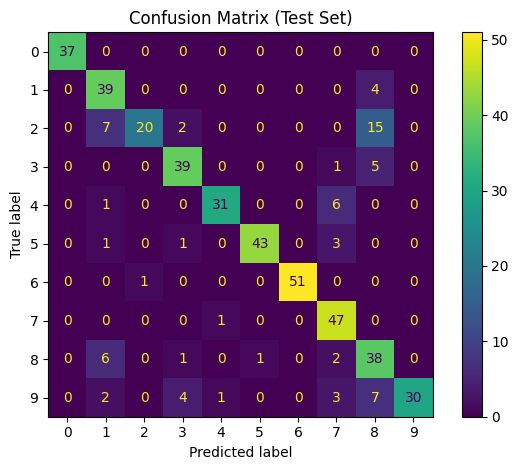

In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, accuracy_score)
import matplotlib.pyplot as plt
import math

# feature engineering
digits = load_digits()
y = digits.target # target labels
X = digits.images.reshape((len(digits.images), -1))

# select model
gnb = GaussianNB()

# split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

# train model on training sets
gnb.fit(X_train, y_train)

# test model
y_pred = gnb.predict(X_test)            # predictions on testing sets

# validate model - accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:2f} \n")

# validate model - confusion matrix: 
# a confusion matrix is a matrix showing how wrongly (or correctly) a model predicted, how much it got “confused.”

print('Confusion Matrix (Text Mode)')
print(confusion_matrix(y_test, y_pred),'\n') # text mode of confusion matrix
print('# of correct predictions:', confusion_matrix(y_test, y_pred).trace(),'\n') # sum of diagonal elements


print('Confusion Matrix (Display Mode)')
disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred) # display mode of confusion matrix
disp.ax_.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.show()

## Step 6: presentation

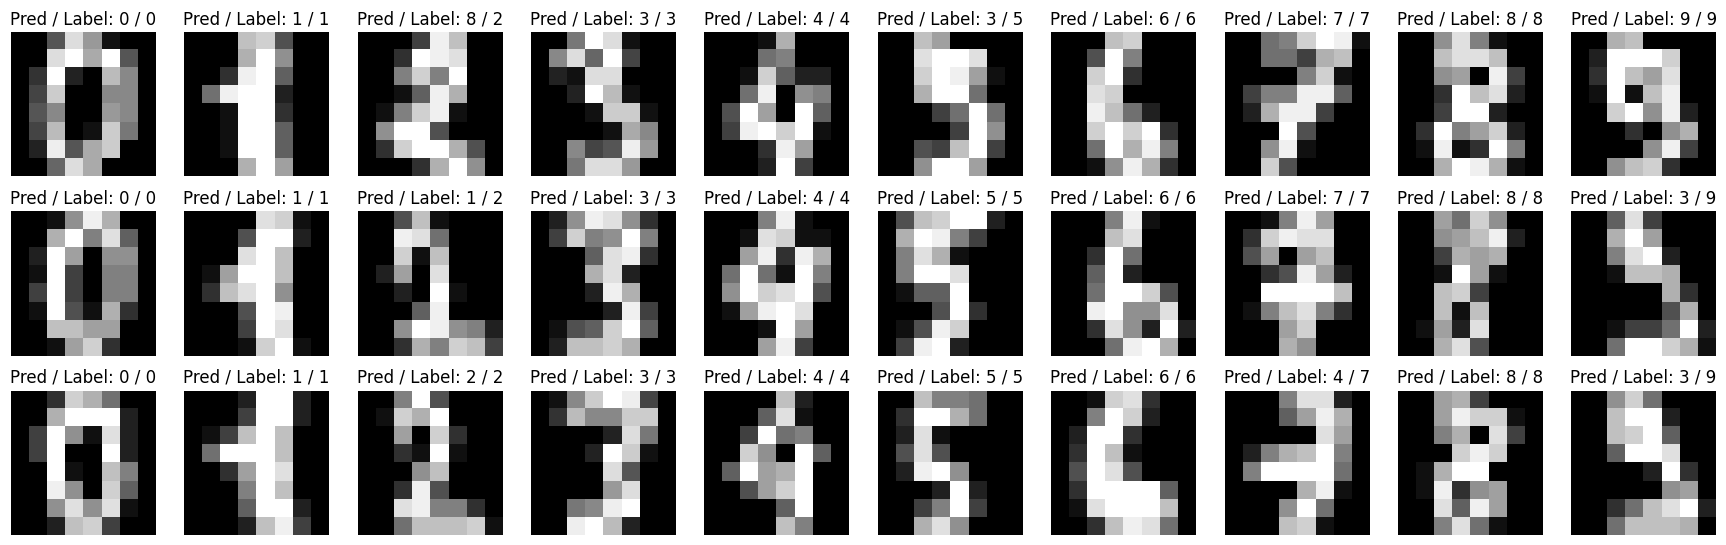

In [4]:
# use the trained model to predict all images
images = digits.images
data_points = digits.images.reshape((len(digits.images), -1))
y_hat_all = gnb.predict(data_points)

n = 30
cols = 10
rows = math.ceil(n / cols)
plt.figure(figsize=(cols * 2.2, rows * 2.2))
for idx in range(n):
    plt.subplot(rows, cols, idx + 1)
    plt.axis("off")
    plt.imshow(images[idx], cmap="gray", interpolation="nearest")
    plt.title(f"Pred / Label: {y_hat_all[idx]} / {y[idx]}")
plt.show()